This is the production part of the project, where we will use machine learning to make an adequet model for fraud detection, it's gonna be ultra effeicent due to our previous EDA.

We will use multiple models to determine which is best for our case.

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, accuracy_score

# Initialize the three competitors
rf_model = RandomForestClassifier(n_estimators=100, random_state=123456, n_jobs=-1)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=123456)
lr_model = LogisticRegression(max_iter=1000)

In [33]:
# Load and Filter the Data
df = pd.read_csv(r'..\data\PS_20174392719_1491204439457_log.csv')
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Recreate our custom features
df_filtered['is_balance_emptied'] = (df_filtered['oldbalanceOrg'] == df_filtered['amount']).astype(int)
df_filtered['dest_error'] = df_filtered['newbalanceDest'] - df_filtered['oldbalanceDest'] - df_filtered['amount']

# Encode type for the models
le = LabelEncoder()
df_filtered['type_code'] = le.fit_transform(df_filtered['type'])

# Define Features X and Target y
features = ['amount', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest', 
            'type_code', 'is_balance_emptied', 'dest_error']
X = df_filtered[features]
y = df_filtered['isFraud']

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123456, stratify=y)

print("Data Prepared for Modeling")

Data Prepared for Modeling


Training Logistic Regression...

Logistic Regression Performance:
Accuracy: 0.9977
AUPRC: 0.4220

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.82      0.28      0.41      1643

    accuracy                           1.00    554082
   macro avg       0.91      0.64      0.71    554082
weighted avg       1.00      1.00      1.00    554082



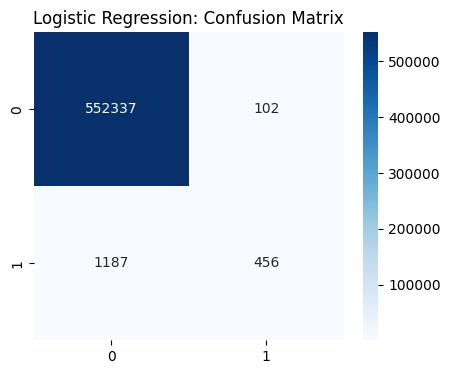

In [34]:
# Logistic Regression
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

Training Random Forest...

Random Forest Performance:
Accuracy: 1.0000
AUPRC: 0.9976

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



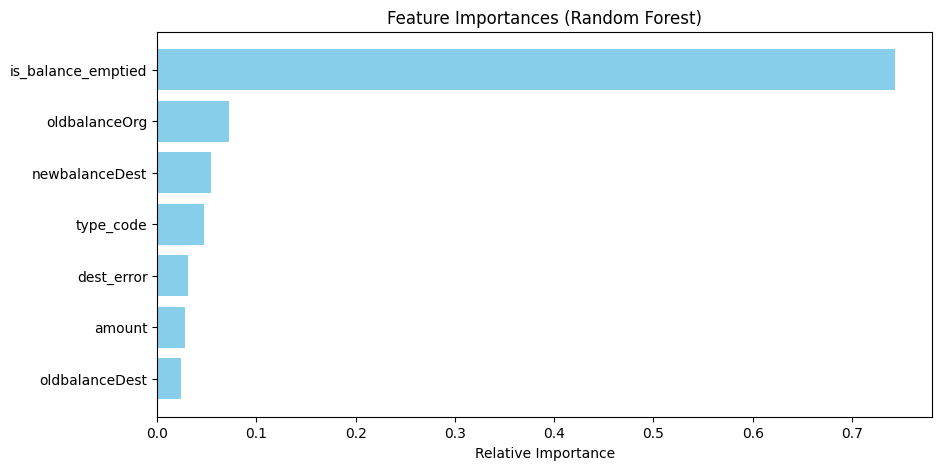

In [35]:
# Random Forest
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance Visualization
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Training XGBoost...


c:\Users\Abdullah\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:53:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Performance:
Accuracy: 0.9996
AUPRC: 0.8831

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.92      0.93      0.92      1643

    accuracy                           1.00    554082
   macro avg       0.96      0.96      0.96    554082
weighted avg       1.00      1.00      1.00    554082



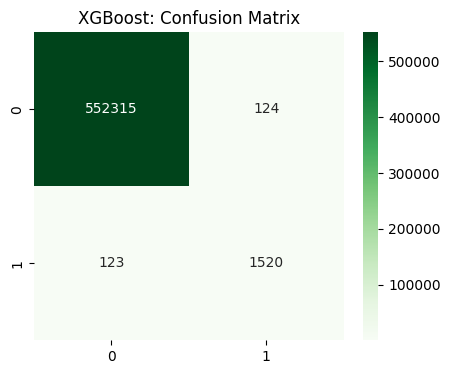

In [36]:
# XGBoost
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("\nXGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost: Confusion Matrix')
plt.show()

In [37]:
# Comparison
from sklearn.metrics import f1_score

summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "F1-Score (Fraud)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "AUPRC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

print("\nComparison Table:")
print(summary.sort_values(by='F1-Score (Fraud)', ascending=False))


Comparison Table:
                 Model  F1-Score (Fraud)     AUPRC
1        Random Forest          0.998781  0.997573
2              XGBoost          0.924855  0.883074
0  Logistic Regression          0.414357  0.421969


With an F1-Score of 0.9987 and an AUPRC of 0.9975, the random forest model is performing at a nearly perfect level. 

This means it is catching almost every single fraudster while maintaining an extremely low rate of false alarms for legitimate customers.

We'll pickle the model in order to deploy it.

In [38]:
import joblib
import os

os.makedirs('../src', exist_ok=True)

# we will save the random forest model as it is the best for our case
joblib.dump(rf_model, '../src/fraud_model.pkl')

print("Random Forest saved to src/fraud_model.pkl")

Random Forest saved to src/fraud_model.pkl
